In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv('Elect.csv', on_bad_lines='skip')
df.info()

/tmp/ipython-input-3716025744.py:1: DtypeWarning: Columns (4,5,10,11,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Elect.csv', on_bad_lines='skip')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208008 entries, 0 to 208007
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         208008 non-null  object 
 1   County                                             208006 non-null  object 
 2   City                                               208005 non-null  object 
 3   State                                              208005 non-null  object 
 4   Postal Code                                        208003 non-null  object 
 5   Model Year                                         208003 non-null  object 
 6   Make                                               208003 non-null  object 
 7   Model                                              208002 non-null  object 
 8   Electric Vehicle Type                              208001 non-null  object

In [5]:
# Show missing % per column
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

                                                   Missing Count  Missing %
Legislative District                                         259   0.124514
2020 Census Tract                                             27   0.012980
Vehicle Location                                              23   0.011057
Electric Utility                                              22   0.010577
DOL Vehicle ID                                                16   0.007692
Base MSRP                                                     11   0.005288
Electric Range                                                10   0.004808
Clean Alternative Fuel Vehicle (CAFV) Eligibility              9   0.004327
Electric Vehicle Type                                          7   0.003365
Model                                                          6   0.002885
Model Year                                                     5   0.002404
Make                                                           5   0.002404
Postal Code 

In [7]:
# Optional: drop rows missing critical fields
df_clean = df.dropna(subset=['Model Year', 'Electric Range', 'Make', 'Model'],inplace=True)
#print(f"Rows after dropping critical missing: {len(df_clean)}")

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 207998 entries, 0 to 208007
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         207998 non-null  object 
 1   County                                             207996 non-null  object 
 2   City                                               207996 non-null  object 
 3   State                                              207998 non-null  object 
 4   Postal Code                                        207996 non-null  object 
 5   Model Year                                         207998 non-null  object 
 6   Make                                               207998 non-null  object 
 7   Model                                              207998 non-null  object 
 8   Electric Vehicle Type                              207998 non-null  object 
 9 

In [9]:
df.isnull().sum()

,0
VIN (1-10),0
County,2
City,2
State,0
Postal Code,2
Model Year,0
Make,0
Model,0
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0


In [11]:
df.duplicated().sum()
df = df.drop_duplicates()


In [12]:
df["Model Year"] = pd.to_numeric(df["Model Year"], errors="coerce")
df["Electric Range"] = pd.to_numeric(df["Electric Range"], errors="coerce")
df["Base MSRP"] = pd.to_numeric(df["Base MSRP"], errors="coerce")


In [13]:
#1.Total vehicles
df["Electric Vehicle Type"].value_counts()


,count
Electric Vehicle Type,
Battery Electric Vehicle (BEV),161468
Plug-in Hybrid Electric Vehicle (PHEV),46519
0,2
B range,1
Battery EEligibility unknown as battery range has not been researched,1
200,1
209825647,1
Battery Electric Alternative Fuel Vehicle Eligible,1
236430099,1


In [16]:
#2. Average electric Range
Average_electric_range = df["Electric Range"].mean()
print(Average_electric_range)


254937.816964994


In [17]:
#3. Total BEV Vehicles and % of Total BEV Vehicles
total_vehicles = len(df)
bev_vehicles = len(df[df["Electric Vehicle Type"] == "Battery Electric Vehicle (BEV)"])
bev_percentage = (bev_vehicles / total_vehicles) * 100
bev_vehicles, bev_percentage

(161468, 77.62959259223646)

In [18]:
#4. Total PhEV Vehicles and % of Total PHEV Vehicles
total_vehicles = len(df)
phev_count = df[df["Electric Vehicle Type"] == "Plug-in Hybrid Electric Vehicle (PHEV)"].shape[0]

phev_percentage = (phev_count / total_vehicles) * 100

phev_count, phev_percentage


(46519, 22.365118895373996)

# Vistualizations

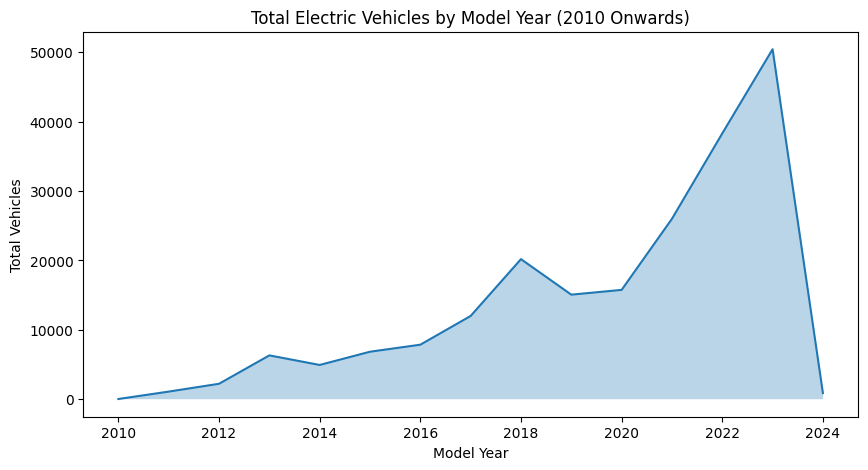

In [19]:
#5. Total Vehicles by Model Year (From 2010 Onwards):
df["Model Year"] = pd.to_numeric(df["Model Year"], errors="coerce")

vehicles_by_year = (
    df[df["Model Year"] >= 2010]
    .groupby("Model Year")
    .size()
    .sort_index()
)

plt.figure(figsize=(10,5))
plt.plot(vehicles_by_year.index, vehicles_by_year.values)
plt.fill_between(vehicles_by_year.index, vehicles_by_year.values, alpha=0.3)
plt.xlabel("Model Year")
plt.ylabel("Total Vehicles")
plt.title("Total Electric Vehicles by Model Year (2010 Onwards)")
plt.show()


In [20]:
#6. Total Vehicles by State:
import plotly.express as px

state_counts = (
    df.groupby("State")
    .size()
    .reset_index(name="Total Vehicles")
)

fig = px.choropleth(
    state_counts,
    locations="State",
    locationmode="USA-states",
    color="Total Vehicles",
    scope="usa",
    title="Total Electric Vehicles by State",
    color_continuous_scale="Viridis"
)

fig.show()


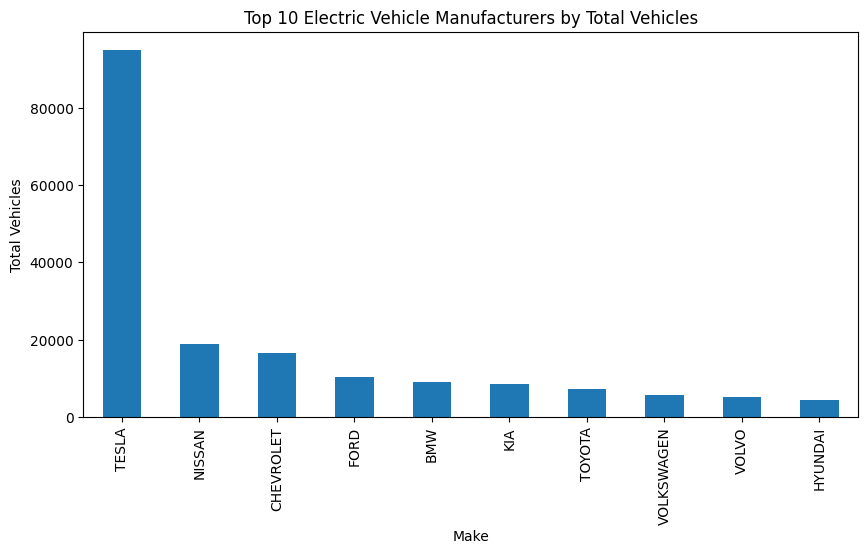

In [21]:
#7. Top 10 Total Vehicles by Make
top_10_makes = (
    df.groupby("Make")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
top_10_makes.plot(kind="bar")
plt.xlabel("Make")
plt.ylabel("Total Vehicles")
plt.title("Top 10 Electric Vehicle Manufacturers by Total Vehicles")
plt.show()


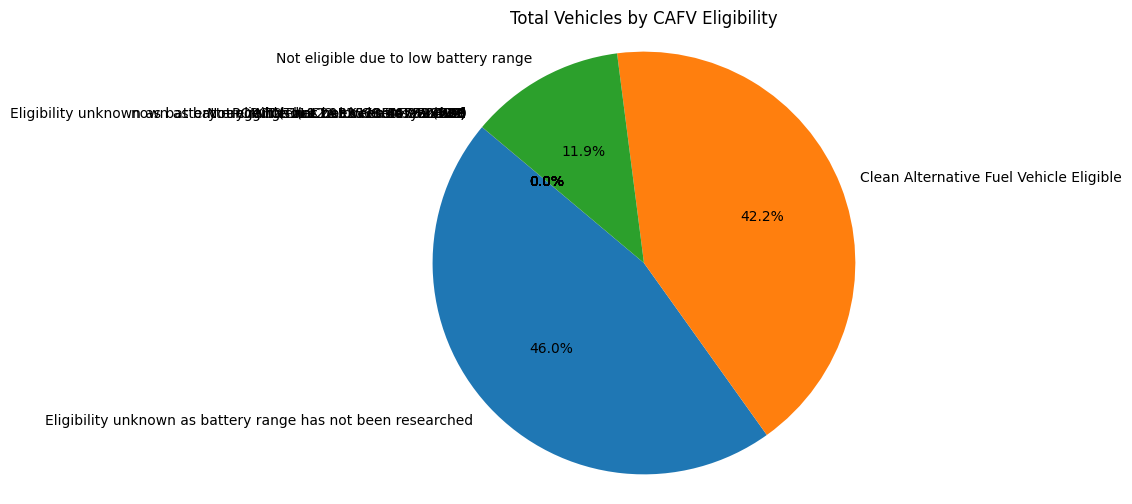

In [22]:
#8. Total Vehicles by CAFV Eligibility
cafv_counts = (
    df["Clean Alternative Fuel Vehicle (CAFV) Eligibility"]
    .value_counts()
)

plt.figure(figsize=(6,6))
plt.pie(
    cafv_counts.values,
    labels=cafv_counts.index,
    autopct="%1.1f%%",
    startangle=140
)
plt.title("Total Vehicles by CAFV Eligibility")
plt.axis("equal")
plt.show()


In [23]:
#9. Top 10 Total Vehicles by Model
import plotly.express as px

top_10_models = (
    df.groupby("Model")
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="Total Vehicles")
)

fig = px.treemap(
    top_10_models,
    path=["Model"],
    values="Total Vehicles",
    title="Top 10 Electric Vehicle Models by Total Vehicles"
)

fig.show()
